# Tyre Degradation Model & Monte Carlo Race Strategy Simulator
### Monza 2024 Race — Charles Leclerc

This notebook builds a data-driven tyre degradation model from real FastF1 race data, then uses it as the foundation for a Monte Carlo race strategy simulator.

**Methodology note:** Outlier laps are only removed when there is an independent, documented justification (e.g. a confirmed pit lap via `PitInTime`). A lap is never removed just because it looks statistically unusual — this avoids cherry-picking results.


In [57]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set up cache
os.makedirs("f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("f1_cache")

# Load the Monza 2024 race session data 
session = fastf1.get_session(2024, "Monza", "R")
session.load()

print("Race data loaded successfully!")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Race data loaded successfully!


In [58]:
# Get all laps for Leclerc during the race
leclerc_laps = session.laps.pick_drivers("LEC")

# Show which tyre compounds he used and how many laps per stint
stint_summary = leclerc_laps.groupby(["Stint", "Compound"])["LapNumber"].count()
print(stint_summary)

Stint  Compound
1.0    MEDIUM      15
2.0    HARD        38
Name: LapNumber, dtype: int64


## Part 1: Tyre Degradation Analysis

### Stint 2 (Hard Compound)


In [59]:
# Filter only Stint 2 (the long Hard-tyre stint)
stint2 = leclerc_laps[leclerc_laps["Stint"] == 2.0]

# remove laps affected by pit stops, safety cars, etc.
stint2 = stint2.pick_quicklaps()

# Convert LapTime from Timedelta to seconds
stint2 = stint2.copy()
stint2["LapTimeSeconds"] = stint2["LapTime"].dt.total_seconds()

print(f"Number of clean laps in stint: {len(stint2)}")
print(stint2[["LapNumber", "LapTimeSeconds", "TyreLife"]].head(10))

Number of clean laps in stint: 37
    LapNumber  LapTimeSeconds  TyreLife
16       17.0          84.270       2.0
17       18.0          83.875       3.0
18       19.0          84.203       4.0
19       20.0          83.826       5.0
20       21.0          83.880       6.0
21       22.0          83.768       7.0
22       23.0          83.864       8.0
23       24.0          83.640       9.0
24       25.0          83.590      10.0
25       26.0          83.321      11.0


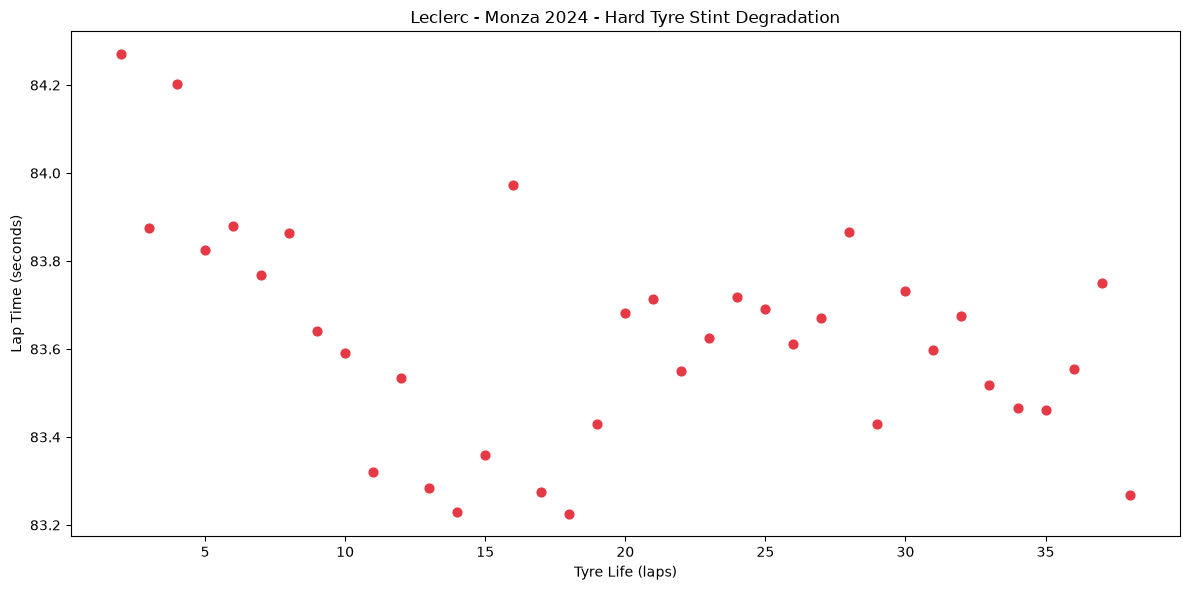

In [60]:
# Plot lap time vs tyre age to visualize degradation
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint2["TyreLife"], stint2["LapTimeSeconds"], color="#e63946", s=40)

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Hard Tyre Stint Degradation")
plt.tight_layout()
plt.show()

In [61]:
# Sort by tyre life and display all laps with their lap times
stint2_sorted = stint2.sort_values("TyreLife")
print(stint2_sorted[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]].to_string(index=False))

 LapNumber  TyreLife  LapTimeSeconds TrackStatus
      17.0       2.0          84.270           1
      18.0       3.0          83.875           1
      19.0       4.0          84.203           1
      20.0       5.0          83.826           1
      21.0       6.0          83.880           1
      22.0       7.0          83.768           1
      23.0       8.0          83.864           1
      24.0       9.0          83.640           1
      25.0      10.0          83.590           1
      26.0      11.0          83.321           1
      27.0      12.0          83.534           1
      28.0      13.0          83.284           1
      29.0      14.0          83.229           1
      30.0      15.0          83.359           1
      31.0      16.0          83.972           1
      32.0      17.0          83.274           1
      33.0      18.0          83.226           1
      34.0      19.0          83.430           1
      35.0      20.0          83.681           1
      36.0      21.0

In [62]:
# Find laps with unusually high lap times (potential outliers)
mean_time = stint2["LapTimeSeconds"].mean()
std_time = stint2["LapTimeSeconds"].std()

print(f"Average lap time: {mean_time:.3f}s")
print(f"Standard deviation: {std_time:.3f}s")

# Show laps that are more than 1.5 standard deviations slower than average
outliers = stint2[stint2["LapTimeSeconds"] > mean_time + 1.5 * std_time]
print("\nPotential outlier laps:")
print(outliers[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]])

Average lap time: 83.625s
Standard deviation: 0.249s

Potential outlier laps:
    LapNumber  TyreLife  LapTimeSeconds TrackStatus
16       17.0       2.0          84.270           1
18       19.0       4.0          84.203           1


In [63]:
# Remove the tyre warm-up phase (first 4 laps) to isolate pure degradation behavior
stint2_clean = stint2[stint2["TyreLife"] > 4].copy()

print(f"Laps remaining after removing warm-up phase: {len(stint2_clean)}")

Laps remaining after removing warm-up phase: 34


In [64]:
from sklearn.linear_model import LinearRegression

X = stint2_clean[["TyreLife"]].values
y = stint2_clean["LapTimeSeconds"].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (degradation rate): {slope:.4f} seconds per lap")
print(f"Intercept: {intercept:.3f} seconds")

Slope (degradation rate): -0.0024 seconds per lap
Intercept: 83.633 seconds


R² (coefficient of determination): 0.0136
This means TyreLife explains 1.4% of the variance in lap times


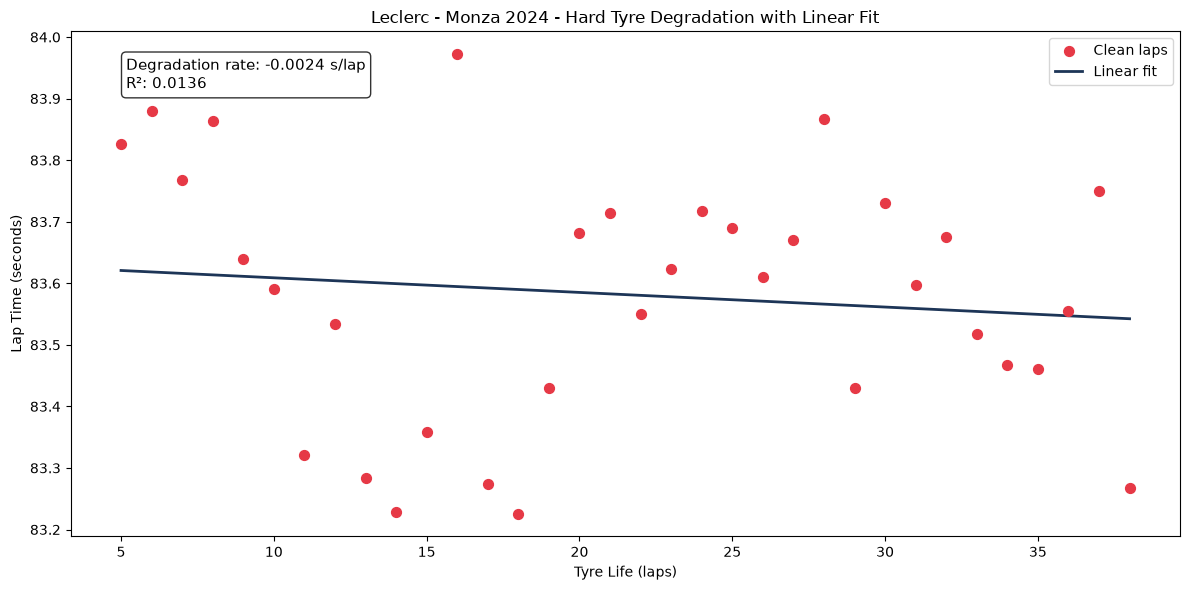

In [65]:
# Generate predictions across the full tyre life range for a smooth regression line
tyre_life_range = np.linspace(stint2_clean["TyreLife"].min(), stint2_clean["TyreLife"].max(), 100).reshape(-1, 1)
predicted_laptimes = model.predict(tyre_life_range)

# Calculate R² to quantify how much variance TyreLife actually explains
r_squared = model.score(X, y)
print(f"R² (coefficient of determination): {r_squared:.4f}")
print(f"This means TyreLife explains {r_squared*100:.1f}% of the variance in lap times")

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint2_clean["TyreLife"], stint2_clean["LapTimeSeconds"], 
           color="#e63946", s=50, zorder=3, label="Clean laps")

ax.plot(tyre_life_range, predicted_laptimes, 
        color="#1d3557", linewidth=2, zorder=2, label="Linear fit")

# Annotate the slope directly on the plot
ax.text(0.05, 0.95, f"Degradation rate: {slope:.4f} s/lap\nR²: {r_squared:.4f}", 
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Hard Tyre Degradation with Linear Fit")
ax.legend()
plt.tight_layout()
plt.show()

### Stint 1 (Medium Compound)


In [66]:
# Filter Stint 1 (Medium tyre) and apply the same cleaning steps as Stint 2
stint1 = leclerc_laps[leclerc_laps["Stint"] == 1.0]
stint1 = stint1.pick_quicklaps()
stint1 = stint1.copy()
stint1["LapTimeSeconds"] = stint1["LapTime"].dt.total_seconds()

print(f"Number of clean laps in Stint 1: {len(stint1)}")

# Remove the tyre warm-up phase (first 4 laps), same threshold as Stint 2 for consistency
stint1_clean = stint1[stint1["TyreLife"] > 4].copy()
print(f"Laps remaining after removing warm-up phase: {len(stint1_clean)}")

Number of clean laps in Stint 1: 15
Laps remaining after removing warm-up phase: 11


In [67]:
# Check for outlier laps in Stint 1 using the same method as Stint 2
mean_time_s1 = stint1_clean["LapTimeSeconds"].mean()
std_time_s1 = stint1_clean["LapTimeSeconds"].std()
print(f"Stint 1 - Average lap time: {mean_time_s1:.3f}s")
print(f"Stint 1 - Standard deviation: {std_time_s1:.3f}s")

outliers_s1 = stint1_clean[stint1_clean["LapTimeSeconds"] > mean_time_s1 + 1.5 * std_time_s1]
print("\nPotential outlier laps in Stint 1:")
print(outliers_s1[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]])

Stint 1 - Average lap time: 85.287s
Stint 1 - Standard deviation: 1.680s

Potential outlier laps in Stint 1:
    LapNumber  TyreLife  LapTimeSeconds TrackStatus
14       15.0      15.0          90.192           1


In [68]:
# Check if Lap 15 was a pit-in lap (which would explain the abnormally slow time)
lap15_check = leclerc_laps[leclerc_laps["LapNumber"] == 15][["LapNumber", "PitInTime", "PitOutTime", "TyreLife", "Stint"]]
print(lap15_check) 

    LapNumber              PitInTime PitOutTime  TyreLife  Stint
14       15.0 0 days 01:17:08.772000        NaT      15.0    1.0


In [69]:
# Remove Lap 15 - confirmed to be the pit-in lap (not representative of pure tyre degradation)
stint1_clean = stint1_clean[stint1_clean["LapNumber"] != 15]
print(f"Laps remaining after removing pit-in lap: {len(stint1_clean)}")

Laps remaining after removing pit-in lap: 10


In [70]:
# Fit linear regression on Stint 1 (Medium tyre)
X_s1 = stint1_clean[["TyreLife"]].values
y_s1 = stint1_clean["LapTimeSeconds"].values

model_s1 = LinearRegression()
model_s1.fit(X_s1, y_s1)

slope_s1 = model_s1.coef_[0]
intercept_s1 = model_s1.intercept_
r_squared_s1 = model_s1.score(X_s1, y_s1)

print(f"Stint 1 (Medium) - Slope: {slope_s1:.4f} seconds per lap")
print(f"Stint 1 (Medium) - Intercept: {intercept_s1:.3f} seconds")
print(f"Stint 1 (Medium) - R²: {r_squared_s1:.4f}")

Stint 1 (Medium) - Slope: 0.1115 seconds per lap
Stint 1 (Medium) - Intercept: 83.737 seconds
Stint 1 (Medium) - R²: 0.5801


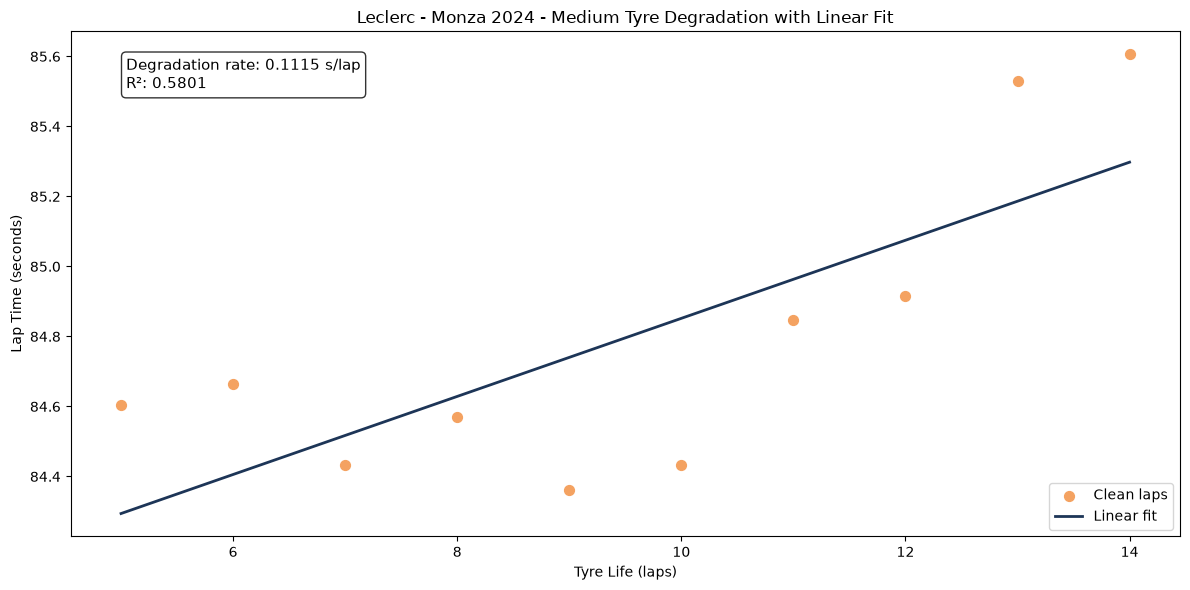

In [71]:
# Generate predictions for a smooth regression line
tyre_life_range_s1 = np.linspace(stint1_clean["TyreLife"].min(), stint1_clean["TyreLife"].max(), 100).reshape(-1, 1)
predicted_laptimes_s1 = model_s1.predict(tyre_life_range_s1)

# Plot Stint 1 (Medium) degradation
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint1_clean["TyreLife"], stint1_clean["LapTimeSeconds"], 
           color="#f4a261", s=50, zorder=3, label="Clean laps")

ax.plot(tyre_life_range_s1, predicted_laptimes_s1, 
        color="#1d3557", linewidth=2, zorder=2, label="Linear fit")

ax.text(0.05, 0.95, f"Degradation rate: {slope_s1:.4f} s/lap\nR²: {r_squared_s1:.4f}", 
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Medium Tyre Degradation with Linear Fit")
ax.legend()
plt.tight_layout()
plt.show() 

### Compound Comparison

Side-by-side view of both compounds on a shared y-axis, to compare degradation slope and signal strength directly.


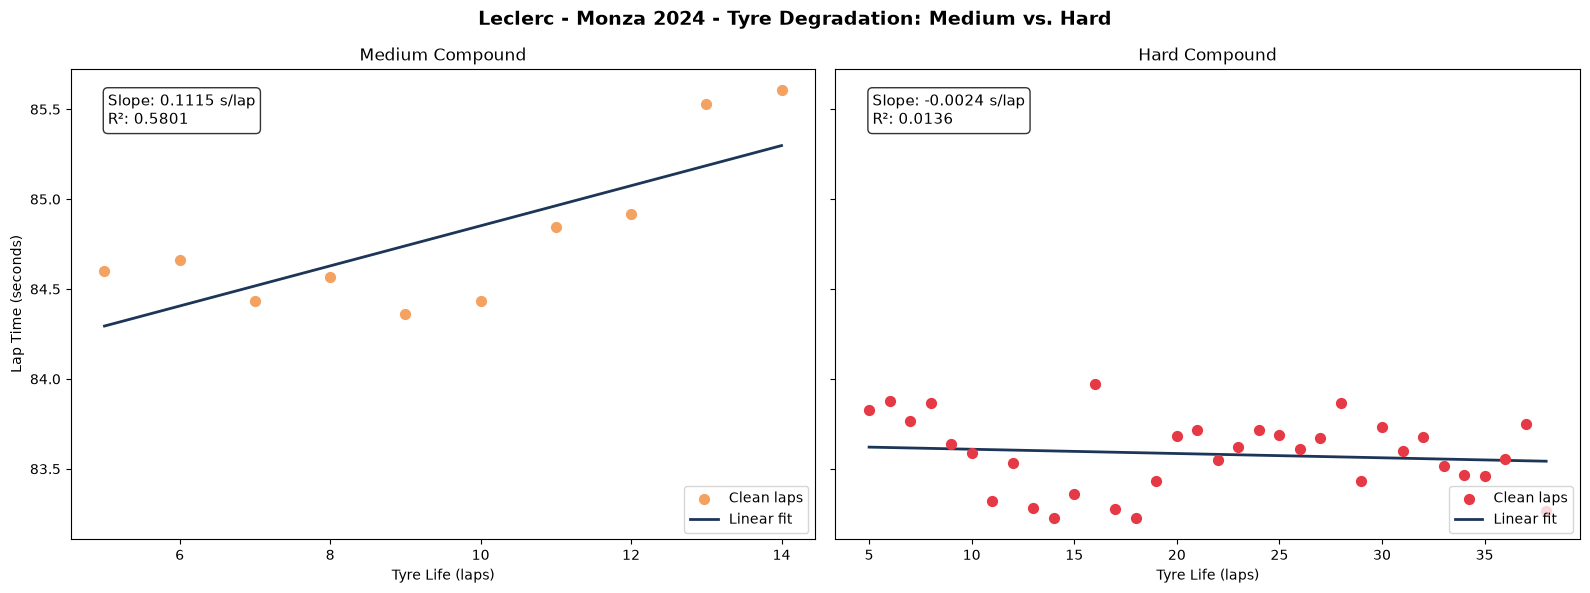

In [72]:
# Create a side-by-side comparison of both compounds' degradation behavior
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Left subplot: Medium tyre (Stint 1) ---
axes[0].scatter(stint1_clean["TyreLife"], stint1_clean["LapTimeSeconds"], 
                 color="#f4a261", s=50, zorder=3, label="Clean laps")
axes[0].plot(tyre_life_range_s1, predicted_laptimes_s1, 
              color="#1d3557", linewidth=2, zorder=2, label="Linear fit")
axes[0].text(0.05, 0.95, f"Slope: {slope_s1:.4f} s/lap\nR²: {r_squared_s1:.4f}", 
              transform=axes[0].transAxes, fontsize=11, verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axes[0].set_xlabel("Tyre Life (laps)")
axes[0].set_ylabel("Lap Time (seconds)")
axes[0].set_title("Medium Compound")
axes[0].legend(loc="lower right")

# --- Right subplot: Hard tyre (Stint 2) ---
axes[1].scatter(stint2_clean["TyreLife"], stint2_clean["LapTimeSeconds"], 
                 color="#e63946", s=50, zorder=3, label="Clean laps")
axes[1].plot(tyre_life_range, predicted_laptimes, 
              color="#1d3557", linewidth=2, zorder=2, label="Linear fit")
axes[1].text(0.05, 0.95, f"Slope: {slope:.4f} s/lap\nR²: {r_squared:.4f}", 
              transform=axes[1].transAxes, fontsize=11, verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axes[1].set_xlabel("Tyre Life (laps)")
axes[1].set_title("Hard Compound")
axes[1].legend(loc="lower right")

fig.suptitle("Leclerc - Monza 2024 - Tyre Degradation: Medium vs. Hard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show() 

## Part 2: Monte Carlo Race Strategy Simulator

### Step 1: Estimating the Fuel-Burn Effect from Real Race Data

Over a race, lap times get faster as fuel burns off, independent of tyre wear. Before modelling degradation for the simulator, we isolate this fuel-burn effect so it isn't mistaken for (or hidden inside) the tyre degradation signal.


In [73]:
# Prepare the full race dataset (both stints combined) for fuel-burn estimation
race_laps = leclerc_laps.pick_quicklaps().copy()
race_laps["LapTimeSeconds"] = race_laps["LapTime"].dt.total_seconds()

# Remove the same warm-up phase per stint (TyreLife > 4), consistent with our stint-level analysis
race_laps_clean = race_laps[race_laps["TyreLife"] > 4].copy()

# Remove the confirmed pit-in lap (Lap 15), same justification as before
race_laps_clean = race_laps_clean[race_laps_clean["LapNumber"] != 15]

print(f"Total clean laps across full race: {len(race_laps_clean)}")
print(race_laps_clean[["LapNumber", "Stint", "TyreLife", "LapTimeSeconds"]].to_string(index=False)) 

Total clean laps across full race: 44
 LapNumber  Stint  TyreLife  LapTimeSeconds
       5.0    1.0       5.0          84.603
       6.0    1.0       6.0          84.663
       7.0    1.0       7.0          84.434
       8.0    1.0       8.0          84.569
       9.0    1.0       9.0          84.362
      10.0    1.0      10.0          84.432
      11.0    1.0      11.0          84.846
      12.0    1.0      12.0          84.916
      13.0    1.0      13.0          85.529
      14.0    1.0      14.0          85.606
      20.0    2.0       5.0          83.826
      21.0    2.0       6.0          83.880
      22.0    2.0       7.0          83.768
      23.0    2.0       8.0          83.864
      24.0    2.0       9.0          83.640
      25.0    2.0      10.0          83.590
      26.0    2.0      11.0          83.321
      27.0    2.0      12.0          83.534
      28.0    2.0      13.0          83.284
      29.0    2.0      14.0          83.229
      30.0    2.0      15.0          8

In [74]:
# Add a binary compound indicator (0 = Medium, 1 = Hard) so the model can separate 
# the fuel-burn effect (LapNumber) from the baseline compound speed difference
race_laps_clean["IsHard"] = (race_laps_clean["Compound"] == "HARD").astype(int)

print(race_laps_clean[["LapNumber", "Compound", "IsHard", "TyreLife", "LapTimeSeconds"]].head(15))

    LapNumber Compound  IsHard  TyreLife  LapTimeSeconds
4         5.0   MEDIUM       0       5.0          84.603
5         6.0   MEDIUM       0       6.0          84.663
6         7.0   MEDIUM       0       7.0          84.434
7         8.0   MEDIUM       0       8.0          84.569
8         9.0   MEDIUM       0       9.0          84.362
9        10.0   MEDIUM       0      10.0          84.432
10       11.0   MEDIUM       0      11.0          84.846
11       12.0   MEDIUM       0      12.0          84.916
12       13.0   MEDIUM       0      13.0          85.529
13       14.0   MEDIUM       0      14.0          85.606
19       20.0     HARD       1       5.0          83.826
20       21.0     HARD       1       6.0          83.880
21       22.0     HARD       1       7.0          83.768
22       23.0     HARD       1       8.0          83.864
23       24.0     HARD       1       9.0          83.640


In [75]:
from sklearn.linear_model import LinearRegression

# Prepare the feature matrix with three inputs: LapNumber (fuel effect), 
# TyreLife (degradation), and IsHard (compound baseline difference)
X_fuel = race_laps_clean[["LapNumber", "TyreLife", "IsHard"]].values
y_fuel = race_laps_clean["LapTimeSeconds"].values

# Fit the multi-feature regression model
model_fuel = LinearRegression()
model_fuel.fit(X_fuel, y_fuel)

# Extract coefficients - order matches the column order in X_fuel
fuel_coef = model_fuel.coef_[0]      # effect of LapNumber (fuel burn)
tyre_coef = model_fuel.coef_[1]      # effect of TyreLife (degradation, now isolated from fuel)
compound_coef = model_fuel.coef_[2]  # effect of IsHard (baseline speed difference)
intercept_fuel = model_fuel.intercept_

r_squared_fuel = model_fuel.score(X_fuel, y_fuel)

print(f"Fuel-burn effect (per lap number): {fuel_coef:.4f} seconds/lap")
print(f"Tyre degradation effect (per tyre life unit): {tyre_coef:.4f} seconds/lap")
print(f"Compound baseline difference (Hard vs Medium): {compound_coef:.4f} seconds")
print(f"Intercept: {intercept_fuel:.3f} seconds")
print(f"R²: {r_squared_fuel:.4f}")

Fuel-burn effect (per lap number): -0.0806 seconds/lap
Tyre degradation effect (per tyre life unit): 0.0810 seconds/lap
Compound baseline difference (Hard vs Medium): -0.0108 seconds
Intercept: 84.792 seconds
R²: 0.7846


In [76]:
# Check correlation between LapNumber and IsHard to quantify the multicollinearity concern
correlation = race_laps_clean[["LapNumber", "TyreLife", "IsHard"]].corr()
print(correlation) 

           LapNumber  TyreLife    IsHard
LapNumber   1.000000  0.924522  0.791664
TyreLife    0.924522  1.000000  0.499058
IsHard      0.791664  0.499058  1.000000


### Step 1b: Isolating the Fuel-Burn Effect (Multi-Driver Approach)

The single-driver model above revealed severe multicollinearity between 
LapNumber and TyreLife (r=0.925), since Leclerc only pitted once. To break 
this collinearity and isolate a reliable fuel-burn coefficient, we extend 
the dataset to include multiple drivers with different pit stop timings.

In [77]:
# Get all laps from all drivers in the race (not just Leclerc)
all_laps = session.laps.pick_quicklaps().copy()
all_laps["LapTimeSeconds"] = all_laps["LapTime"].dt.total_seconds()

# Apply the same warm-up filter as before (per stint, works automatically 
# across all drivers since TyreLife resets at each pit stop)
all_laps_clean = all_laps[all_laps["TyreLife"] > 4].copy()

# Remove any lap that is a confirmed pit-in lap (same justification as Lap 15 
# for Leclerc), now applied across the whole grid using PitInTime directly
all_laps_clean = all_laps_clean[all_laps_clean["PitInTime"].isna()]

print(f"Total clean laps across all drivers: {len(all_laps_clean)}")
print(f"Number of unique drivers: {all_laps_clean['Driver'].nunique()}")

Total clean laps across all drivers: 774
Number of unique drivers: 20


In [78]:
# Check which compounds appear in the full-grid dataset
compound_summary = all_laps_clean.groupby("Compound")["LapNumber"].count()
print(compound_summary)

Compound
HARD      591
MEDIUM    183
Name: LapNumber, dtype: int64


In [79]:
# Add the same binary compound indicator as before
all_laps_clean["IsHard"] = (all_laps_clean["Compound"] == "HARD").astype(int)

# Fit the multi-feature regression model on the full grid
X_fuel_all = all_laps_clean[["LapNumber", "TyreLife", "IsHard"]].values
y_fuel_all = all_laps_clean["LapTimeSeconds"].values

model_fuel_all = LinearRegression()
model_fuel_all.fit(X_fuel_all, y_fuel_all)

fuel_coef_all = model_fuel_all.coef_[0]
tyre_coef_all = model_fuel_all.coef_[1]
compound_coef_all = model_fuel_all.coef_[2]
intercept_fuel_all = model_fuel_all.intercept_

r_squared_fuel_all = model_fuel_all.score(X_fuel_all, y_fuel_all)

print(f"Fuel-burn effect (per lap number): {fuel_coef_all:.4f} seconds/lap")
print(f"Tyre degradation effect (per tyre life unit): {tyre_coef_all:.4f} seconds/lap")
print(f"Compound baseline difference (Hard vs Medium): {compound_coef_all:.4f} seconds")
print(f"Intercept: {intercept_fuel_all:.3f} seconds")
print(f"R²: {r_squared_fuel_all:.4f}")

Fuel-burn effect (per lap number): -0.0620 seconds/lap
Tyre degradation effect (per tyre life unit): 0.0643 seconds/lap
Compound baseline difference (Hard vs Medium): -0.3231 seconds
Intercept: 85.786 seconds
R²: 0.4714


In [80]:
# Verify that multicollinearity has actually been reduced with the multi-driver dataset
correlation_all = all_laps_clean[["LapNumber", "TyreLife", "IsHard"]].corr()
print(correlation_all)

           LapNumber  TyreLife    IsHard
LapNumber   1.000000  0.538771  0.277066
TyreLife    0.538771  1.000000  0.323000
IsHard      0.277066  0.323000  1.000000


## Step 2: Modeling Lap Time Noise

The simulator needs a random component so simulated lap times scatter realistically around the model prediction, instead of falling exactly on the regression line. This scatter is estimated from the **residuals** of the multi-driver model (actual lap time minus predicted lap time) - i.e. the variation left over once fuel-burn, degradation and compound are already accounted for.

In [81]:
# Calculate residuals: the difference between actual lap times and what 
# the fuel+degradation+compound model predicted for each lap
predicted_all = model_fuel_all.predict(X_fuel_all)
residuals_all = y_fuel_all - predicted_all

print(f"Mean residual: {residuals_all.mean():.4f}s (should be ~0)")
print(f"Residual standard deviation: {residuals_all.std():.4f}s")

Mean residual: -0.0000s (should be ~0)
Residual standard deviation: 0.8302s


In [82]:
# Check whether residual variance differs meaningfully between compounds
residuals_df = all_laps_clean.copy()
residuals_df["Residual"] = residuals_all

residual_std_by_compound = residuals_df.groupby("Compound")["Residual"].std()
print(residual_std_by_compound)

Compound
HARD      0.815128
MEDIUM    0.881772
Name: Residual, dtype: float64


**Result:** Hard (σ = 0.815s) and Medium (σ = 0.882s) show a moderate difference, consistent with the stronger non-linear degradation behaviour observed for Medium earlier. Compound-specific noise values are used in the simulator rather than a single global value, for consistency with how the other parameters (degradation, fuel-burn interaction) were also estimated per compound.

## Step 3: Pit Stop Time Loss

`PitInTime` and `PitOutTime` mark the moments a driver crosses the pit entry and exit lines. Their difference is the full time spent in the pit lane (entry, tyre change, exit) - the raw pit lane duration. This is not yet the net time loss of a stop relative to the field; that is derived in Step 4.

In [83]:
# Diagnose: check how PitInTime and PitOutTime are actually distributed across rows
sample_driver = session.laps.pick_drivers("LEC")
print(sample_driver[["LapNumber", "PitInTime", "PitOutTime"]].dropna(how="all", subset=["PitInTime", "PitOutTime"]))

    LapNumber              PitInTime             PitOutTime
14       15.0 0 days 01:17:08.772000                    NaT
15       16.0                    NaT 0 days 01:17:33.191000


`PitInTime` and `PitOutTime` are split across two separate rows (the in-lap and the following out-lap), not stored together on one row. The two need to be aligned per driver before a pit duration can be calculated.

In [84]:
# For each driver, sort by lap number and pair each PitInTime with the PitOutTime 
# of the immediately following lap (since FastF1 splits them across two rows)
laps_sorted = session.laps.sort_values(["Driver", "LapNumber"]).copy()

# Shift PitOutTime up by one row *within each driver* to align it with the PitInTime row
laps_sorted["NextPitOutTime"] = laps_sorted.groupby("Driver")["PitOutTime"].shift(-1)

# Now filter to rows where PitInTime is set - these are confirmed pit-in laps
pit_laps = laps_sorted[laps_sorted["PitInTime"].notna()].copy()

# Calculate pit duration using the aligned PitOutTime
pit_laps["PitDuration"] = (pit_laps["NextPitOutTime"] - pit_laps["PitInTime"]).dt.total_seconds()

print(f"Number of completed pit stops detected: {pit_laps['PitDuration'].notna().sum()}")
print(pit_laps["PitDuration"].describe())

Number of completed pit stops detected: 30
count    30.000000
mean     26.164467
std       3.709682
min      23.763000
25%      24.304000
50%      24.783000
75%      25.559750
max      38.845000
Name: PitDuration, dtype: float64


In [85]:
# Identify which driver/lap the slowest pit stop belongs to, to check for an independent cause
slowest_stop = pit_laps.loc[pit_laps["PitDuration"].idxmax()]
print(slowest_stop[["Driver", "LapNumber", "PitDuration", "TrackStatus"]])

Driver            HUL
LapNumber         5.0
PitDuration    38.845
TrackStatus         1
dtype: object


**Result:** The slowest stop (HUL, Lap 5, 38.85s) shows `TrackStatus = 1` (green flag), so there is no independently documented cause (Safety Car, yellow flag) to justify removing it - and the very early lap number (5, well before typical strategy windows) suggests an unplanned event such as car damage, which `TrackStatus` would not capture either way. Consistent with the project's rule of only removing laps with independent justification, the value is kept. To stay robust against this single outlier, the **median** rather than the mean is used as the pit lane duration.

In [86]:
# Median pit lane duration (entry line to exit line),
# since it is robust to the single unexplained outlier (HUL, Lap 5)
pit_lane_duration_median = pit_laps["PitDuration"].median()
print(f"Median pit lane duration: {pit_lane_duration_median:.3f} seconds")

Median pit lane duration: 24.783 seconds


## Step 4: Safety Car Modelling and Net Pit Stop Loss

The simulator needs three safety-car-related inputs: how likely a safety car is, how much slower laps are under it, and how much cheaper a pit stop becomes. Monza 2024 itself was fully green (a sample of one), so these inputs come from several Monza races and from an external long-term rate. Because the data base is thin, the safety car probability is treated as a **scenario parameter** (sensitivity analysis) rather than a single fixed value.

### 4a: Safety car probability

In [87]:
# Convert a per-race safety car probability into a per-lap probability,
# assuming independent laps (Monza 2024 race distance: 53 laps)
total_laps = 53

def race_to_lap_probability(p_race, n_laps=total_laps):
    return 1 - (1 - p_race) ** (1 / n_laps)

# Scenarios: none (= Monza 2024), long-term rate (STATS F1: 29% of Monza races since 1993), own data 2018-2024 (4 of 7 races)
sc_scenarios = {"No safety car": 0.0, "Long-term Monza rate (STATS F1)": 0.29, "Own data 2018-2024": 4 / 7}

for name, p_race in sc_scenarios.items():
    print(f"{name}: p_race={p_race:.2f} -> p_lap={race_to_lap_probability(p_race):.4f}")

No safety car: p_race=0.00 -> p_lap=0.0000
Long-term Monza rate (STATS F1): p_race=0.29 -> p_lap=0.0064
Own data 2018-2024: p_race=0.57 -> p_lap=0.0159


In [88]:
# Track status codes: 1 green, 2 yellow, 4 safety car, 5 red flag, 6/7 virtual safety car
print(session.track_status["Status"].value_counts())

Status
1    1
Name: count, dtype: int64


In [89]:
# Which track statuses occurred in the Monza races 2018-2023? (2024 is known from above)
monza_status = {}

for year in range(2018, 2024):
    past_session = fastf1.get_session(year, "Monza", "R")
    past_session.load(telemetry=False, weather=False, messages=False)
    monza_status[year] = set(past_session.track_status["Status"])

monza_status[2024] = set(session.track_status["Status"])

for year, statuses in monza_status.items():
    print(year, sorted(statuses))

sc_races = [year for year, statuses in monza_status.items() if "4" in statuses]
print(f"Races with a full safety car: {len(sc_races)} of {len(monza_status)} -> {sc_races}")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
logger      WARNING 	Failed to load timing data!
core        WARNING 	Failed to add first lap time from Ergast for drivers: ['7', '44', '33', '77', '8', '55', '31', '18', '35', '14', '10', '20', '11', '16', '2', '27', '3', '5', '9']
core           INFO 	Finished loading data for 20 drivers: ['44', '7', '77', '5', '33', '31', '11', '55', '18', '35', '16', '2', '27', '10', '9', '20', '3', '14', '28', '8']
core           INFO 	Loading data for Italian Grand Prix - Ra

2018 ['1', '2', '4', '6', '7']
2019 ['1', '2', '6', '7']
2020 ['1', '2', '4', '5']
2021 ['1', '2', '4', '6', '7']
2022 ['1', '2', '4', '6', '7']
2023 ['1', '2']
2024 ['1']
Races with a full safety car: 4 of 7 -> [2018, 2020, 2021, 2022]


**Result:** A full safety car (status 4) occurred in 4 of 7 Monza races between 2018 and 2024 (2018, 2020, 2021, 2022), about 57%. This is above the long-term rate of 29%, but with only 7 races the uncertainty is large (a 95% interval spans roughly 25% to 84%), so the two values are not in conflict. The simulator therefore runs three scenarios: no safety car, 29% and 57%.

### 4b: Lap time under safety car

In [90]:
# Lap times in the Monza races with a safety car; skip years where FastF1 has no lap timing data
sc_years = [2018, 2020, 2021, 2022]
history = []

for year in sc_years:
    try:
        hist_session = fastf1.get_session(year, "Monza", "R")
        hist_session.load(telemetry=False, weather=False, messages=False)
        hist_laps = hist_session.laps.copy()
    except Exception as error:
        print(f"Skipping {year}: {error}")
        continue

    hist_laps["Year"] = year
    hist_laps["LapTimeSeconds"] = hist_laps["LapTime"].dt.total_seconds()
    history.append(hist_laps[["Year", "Driver", "LapNumber", "LapTimeSeconds", "TrackStatus", "PitInTime", "PitOutTime"]])

hist_all = pd.concat(history, ignore_index=True)

# Exclude pit laps, since they are slow for reasons unrelated to the safety car
hist_all = hist_all[hist_all["PitInTime"].isna() & hist_all["PitOutTime"].isna()]

# Green laps: TrackStatus exactly "1"; safety car laps: contains "4" but no red flag ("5")
green = hist_all[hist_all["TrackStatus"] == "1"]
sc = hist_all[hist_all["TrackStatus"].str.contains("4") & ~hist_all["TrackStatus"].str.contains("5")]

summary = pd.DataFrame({
    "GreenMedian": green.groupby("Year")["LapTimeSeconds"].median(),
    "SCMedian": sc.groupby("Year")["LapTimeSeconds"].median(),
    "SCLaps": sc.groupby("Year")["LapTimeSeconds"].count(),
})
summary["Ratio"] = summary["SCMedian"] / summary["GreenMedian"]
print(summary)

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
logger      WARNING 	Failed to load timing data!
core        WARNING 	Failed to add first lap time from Ergast for drivers: ['7', '44', '33', '77', '8', '55', '31', '18', '35', '14', '10', '20', '11', '16', '2', '27', '3', '5', '9']
core           INFO 	Finished loading data for 20 drivers: ['44', '7', '77', '5', '33', '31', '11', '55', '18', '35', '16', '2', '27', '10', '9', '20', '3', '14', '28', '8']
core           INFO 	Loading data for Italian Grand Prix - Ra

Skipping 2018: The data you are trying to access has not been loaded yet. See `Session.load`


core        WARNING 	Driver 10 completed the race distance 00:00.067000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['10', '55', '18', '4', '77', '3', '44', '31', '26', '11', '6', '8', '7', '63', '23', '99', '33', '16', '20', '5']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Driver 3 completed the race distance 00:00.086000 before th

      GreenMedian  SCMedian  SCLaps     Ratio
Year                                         
2020       85.729   117.173      69  1.366784
2021       86.917   134.563      33  1.548178
2022       87.199   118.039      91  1.353674


**Result:** 2018 is skipped (FastF1 has no lap timing data for that race). For 2020, 2021 and 2022 a lap under safety car is 1.37x, 1.55x and 1.35x the green-flag lap time. The 2021 value rests on only 33 driver laps, so the **median ratio of about 1.37** is used for the simulator.

### 4c: Net pit stop loss, green vs. safety car

The net loss of a stop is measured **relative to the field**: in-lap plus out-lap, minus the median lap time of all drivers who did not pit in those same lap numbers. Comparing against a driver's own green-flag pace would be wrong under a safety car, because every normal lap is already slow then.

In [91]:
# Net pit stop loss relative to the field: compare in-lap + out-lap against the
# median lap time of all drivers who did NOT pit in that same lap number
stop_tables = []

for year in [2020, 2021, 2022, 2023, 2024]:
    hist_session = fastf1.get_session(year, "Monza", "R")
    hist_session.load(telemetry=False, weather=False, messages=False)

    hist_laps = hist_session.laps.sort_values(["Driver", "LapNumber"]).copy()
    hist_laps["LapTimeSeconds"] = hist_laps["LapTime"].dt.total_seconds()
    hist_laps["TrackStatus"] = hist_laps["TrackStatus"].fillna("")

    # Field pace per lap number, from drivers without any pit involvement in that lap
    no_pit = hist_laps[hist_laps["PitInTime"].isna() & hist_laps["PitOutTime"].isna()]
    field_pace = no_pit.groupby("LapNumber")["LapTimeSeconds"].median()

    # Bring out-lap time and out-lap track status onto the in-lap row
    hist_laps["NextLapTime"] = hist_laps.groupby("Driver")["LapTimeSeconds"].shift(-1)
    hist_laps["NextTrackStatus"] = hist_laps.groupby("Driver")["TrackStatus"].shift(-1).fillna("")

    stops_hist = hist_laps[hist_laps["PitInTime"].notna()].copy()
    stops_hist["Year"] = year
    stops_hist["FieldIn"] = stops_hist["LapNumber"].map(field_pace)
    stops_hist["FieldOut"] = (stops_hist["LapNumber"] + 1).map(field_pace)
    stops_hist["NetLoss"] = (stops_hist["LapTimeSeconds"] + stops_hist["NextLapTime"]
                             - stops_hist["FieldIn"] - stops_hist["FieldOut"])
    stop_tables.append(stops_hist)

stops_hist_all = pd.concat(stop_tables, ignore_index=True).dropna(subset=["NetLoss"])

# Exclude stops affected by a red flag, then flag stops touched by a safety car
combined_status = stops_hist_all["TrackStatus"] + stops_hist_all["NextTrackStatus"]
stops_hist_all = stops_hist_all[~combined_status.str.contains("5")]
combined_status = stops_hist_all["TrackStatus"] + stops_hist_all["NextTrackStatus"]
stops_hist_all["UnderSC"] = combined_status.str.contains("4")

print(stops_hist_all.groupby(["Year", "UnderSC"])["NetLoss"].agg(["count", "median"]))

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 10 completed the race distance 00:00.067000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['10', '55', '18', '4', '77', '3', '44', '31', '26', '11', '6', '8', '7', '63', '23', '99', '33', '16', '20', '5']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_inf

              count    median
Year UnderSC                 
2020 False        6  30.40850
     True        13  33.01250
2021 False        8  26.25500
     True         8  21.87200
2022 False       20  25.28425
     True         7  23.69650
2023 False       25  25.42500
2024 False       30  25.62350


In [92]:
# Strict groups: green = in-lap and out-lap both purely green (excludes VSC and any yellow),
# SC = safety car in in-lap or out-lap, excluding 2020 (pit lane closed, penalties)
status_in = stops_hist_all["TrackStatus"]
status_out = stops_hist_all["NextTrackStatus"]

pure_green = (status_in == "1") & (status_out == "1")
green_stops = stops_hist_all[pure_green]
sc_stops = stops_hist_all[stops_hist_all["UnderSC"] & (stops_hist_all["Year"] != 2020)]

green_median = green_stops["NetLoss"].median()
sc_median = sc_stops["NetLoss"].median()

print(f"Green stops: n={len(green_stops)}, median net loss = {green_median:.2f}s")
print(f"SC stops (2021, 2022): n={len(sc_stops)}, median net loss = {sc_median:.2f}s")
print(f"Estimated saving under SC: {green_median - sc_median:.2f}s")
print(sc_stops["NetLoss"].describe())

Green stops: n=85, median net loss = 25.55s
SC stops (2021, 2022): n=15, median net loss = 22.49s
Estimated saving under SC: 3.06s
count    15.000000
mean     24.253767
std       9.386484
min      10.826500
25%      18.966500
50%      22.492000
75%      26.953500
max      46.038500
Name: NetLoss, dtype: float64


**Result:** Green stops cost a median 25.55s net (n=85, very consistent from 2021 to 2024). Under safety car the median is 22.49s (n=15), a saving of about 3.1s. The spread under safety car is large (10.8s to 46.0s, standard deviation 9.4s), so the standard error of that median is roughly 2.4s and the saving is only about one standard error: **suggestive, not statistically established**. 2020 is excluded from the safety car group because the pit lane was closed after Magnussen stopped at the pit entry, which produced penalties and distorts net losses; this is an externally documented reason and not a data-driven removal.

Practical consequence: a safety car shifts every strategy by the same lap time factor, and only the small difference in stop cost changes the strategy ranking, so the safety car probability is expected to have a modest effect on the best strategy in Monza. The sensitivity analysis will test this.

### Simulator parameters from Step 4

In [93]:
# Parameters passed on to the simulator
sc_lap_time_factor = summary["Ratio"].median()   # lap time under safety car relative to green
net_loss_green = green_median                    # net pit stop loss under green flag (s)
net_loss_sc = sc_median                          # net pit stop loss under safety car (s)

# Empirical samples, so the simulator can draw stop losses with realistic spread instead of a single value
green_losses = green_stops["NetLoss"].values
sc_losses = sc_stops["NetLoss"].values

print(f"Safety car lap time factor: {sc_lap_time_factor:.3f}")
print(f"Net stop loss green: {net_loss_green:.2f}s | under SC: {net_loss_sc:.2f}s")

Safety car lap time factor: 1.367
Net stop loss green: 25.55s | under SC: 22.49s


### Note on the undercut effect

The undercut is a comparison effect: it only exists relative to a competitor who pits later. Since this simulator models a single car with no field, positions, or traffic, there is no reference point to compute an undercut against — any number here would be an unfounded guess, not a data-derived one. Consistent with the project's scope discipline (see driver error, weather, opponent reactions), the undercut is therefore explicitly out of scope and left for future work with a multi-car model.

## Step 5: Compound-Specific Degradation, Isolated from Fuel-Burn

The full-grid model in Step 1c used a single degradation coefficient shared by both compounds, which contradicts the clear Medium/Hard difference found in Part 1. This step fixes that with an interaction term, and checks whether the resulting Hard-compound value is really representative of Leclerc.

In [94]:
# Add an interaction term so degradation can differ by compound, while still
# using the full-grid dataset to keep the fuel-burn estimate free of multicollinearity
all_laps_clean["TyreLife_x_IsHard"] = all_laps_clean["TyreLife"] * all_laps_clean["IsHard"]

X_interact = all_laps_clean[["LapNumber", "TyreLife", "IsHard", "TyreLife_x_IsHard"]].values
y_interact = all_laps_clean["LapTimeSeconds"].values

model_interact = LinearRegression()
model_interact.fit(X_interact, y_interact)

fuel_coef_i = model_interact.coef_[0]
tyre_coef_medium = model_interact.coef_[1]                          # degradation slope for Medium
compound_coef_i = model_interact.coef_[2]
tyre_coef_hard = model_interact.coef_[1] + model_interact.coef_[3]  # Medium slope + interaction = Hard slope

r_squared_interact = model_interact.score(X_interact, y_interact)

print(f"Fuel-burn effect: {fuel_coef_i:.4f} s/lap")
print(f"Degradation - Medium: {tyre_coef_medium:.4f} s/lap")
print(f"Degradation - Hard: {tyre_coef_hard:.4f} s/lap")
print(f"Compound baseline difference (Hard vs Medium): {compound_coef_i:.4f} s")
print(f"R²: {r_squared_interact:.4f}")

Fuel-burn effect: -0.0631 s/lap
Degradation - Medium: 0.1098 s/lap
Degradation - Hard: 0.0626 s/lap
Compound baseline difference (Hard vs Medium): 0.1826 s
R²: 0.4767


**Result:** Medium (0.1098 s/lap) closely matches Leclerc's own single-stint slope (0.1115 s/lap). Hard (0.0626 s/lap) does not match Leclerc's own slope at all (-0.0024 s/lap) - a sign shift, not a rounding difference. Since the Hard sample is dominated by the rest of the field (557 laps vs Leclerc's 34), this value may reflect field-average degradation rather than Leclerc's own tyre behaviour. Checked directly below.

In [95]:
# Compare Leclerc's own Hard-tyre degradation against the rest of the field,
# using the same fuel-adjusted approach (residuals relative to LapNumber only)
hard_only = all_laps_clean[all_laps_clean["IsHard"] == 1].copy()
hard_only["IsLeclerc"] = (hard_only["Driver"] == "LEC").astype(int)

# Fit once on the rest of the field, once on Leclerc only, to compare degradation slopes directly
model_field = LinearRegression().fit(
    hard_only.loc[hard_only["IsLeclerc"] == 0, ["LapNumber", "TyreLife"]].values,
    hard_only.loc[hard_only["IsLeclerc"] == 0, "LapTimeSeconds"].values
)
model_lec = LinearRegression().fit(
    hard_only.loc[hard_only["IsLeclerc"] == 1, ["LapNumber", "TyreLife"]].values,
    hard_only.loc[hard_only["IsLeclerc"] == 1, "LapTimeSeconds"].values
)

print(f"Hard degradation - rest of field: {model_field.coef_[1]:.4f} s/lap (n={(hard_only['IsLeclerc']==0).sum()})")
print(f"Hard degradation - Leclerc only: {model_lec.coef_[1]:.4f} s/lap (n={(hard_only['IsLeclerc']==1).sum()})")

Hard degradation - rest of field: 0.0809 s/lap (n=557)
Hard degradation - Leclerc only: -0.0012 s/lap (n=34)


**Result:** the rest of the field shows a clear, well-sampled Hard degradation of 0.0809 s/lap (n=557), while Leclerc's own value stays at -0.0012 s/lap (n=34) - essentially confirming the original single-stint estimate. This is a genuine finding, not a modelling artifact: Leclerc ran unusually gently on the Hard tyre in this race compared to the rest of the field. The field value is kept as context (it shows the Hard/Medium gap is not a general characteristic of Monza, but specific to how Leclerc drove that stint) but is **not** used as a simulator input, to stay consistent with the project's Monza-2024-Leclerc-specific scope.

**Final decision:** fuel-burn is taken from the field-wide model (a vehicle/physics effect, not driver-specific), while degradation per compound is taken from Leclerc's own single-stint slopes (matches the project scope; the field Hard slope reflects other drivers, not Leclerc).

In [96]:
# Final degradation + fuel parameters for the simulator, combining the most 
# appropriate source for each effect (see reasoning above)
sim_fuel_coef = fuel_coef_i          # field-wide, physics-driven, driver-independent
sim_tyre_medium = slope_s1           # Leclerc's own Medium slope (matches field estimate closely)
sim_tyre_hard = slope                # Leclerc's own Hard slope (field estimate reflects other drivers, not Leclerc)

print(f"Fuel-burn: {sim_fuel_coef:.4f} s/lap")
print(f"Degradation Medium (Leclerc): {sim_tyre_medium:.4f} s/lap")
print(f"Degradation Hard (Leclerc): {sim_tyre_hard:.4f} s/lap")

Fuel-burn: -0.0631 s/lap
Degradation Medium (Leclerc): 0.1115 s/lap
Degradation Hard (Leclerc): -0.0024 s/lap


## Part 3: Building the Simulator

With degradation, fuel-burn, noise, pit-stop loss and safety car parameters all estimated and reconciled in Part 2, this part assembles them into an actual Monte Carlo strategy simulator: one lap at a time, then a full race, then thousands of repeated races per strategy, compared against each other.

### Core function: simulate a single lap

In [97]:
def simulate_lap(lap_number, tyre_life, compound, under_sc, rng):
    """
    Simulate a single lap time in seconds.
    - lap_number: current lap of the race (affects fuel load)
    - tyre_life: laps since the current tyre set was fitted
    - compound: "MEDIUM" or "HARD"
    - under_sc: True if a safety car is out this lap
    - rng: a numpy random Generator, passed in so randomness is controlled centrally
    """
    is_hard = 1 if compound == "HARD" else 0
    degradation_rate = sim_tyre_hard if is_hard else sim_tyre_medium
    noise_std = residual_std_by_compound["HARD" if is_hard else "MEDIUM"]

    base_time = (
        intercept_fuel_all
        + sim_fuel_coef * lap_number
        + degradation_rate * tyre_life
        + compound_coef_i * is_hard
    )

    noise = rng.normal(0, noise_std)
    lap_time = base_time + noise

    if under_sc:
        lap_time *= sc_lap_time_factor

    return lap_time

In [98]:
# Quick sanity check: a Medium lap early in a stint, green flag, fixed seed for reproducibility
test_rng = np.random.default_rng(42)
test_time = simulate_lap(lap_number=10, tyre_life=5, compound="MEDIUM", under_sc=False, rng=test_rng)
print(f"Simulated lap time: {test_time:.3f}s")

Simulated lap time: 85.981s


### Core function: simulate a complete race

A strategy is a list of `(compound, stint_length)` tuples, e.g. `[("MEDIUM", 20), ("HARD", 33)]`. For each lap, `lap_number` runs continuously across the whole race (for the fuel term), while `tyre_life` resets to 1 at the start of every stint (for the degradation term). A pit stop is added at the end of every stint except the last, drawing a net time loss from the empirical green-flag or safety-car samples from Step 4, depending on whether that lap is under a safety car.

In [99]:
def simulate_race(strategy, total_laps, sc_probability, rng):
    """
    Simulate one complete race given a pit strategy.

    strategy: list of (compound, stint_length) tuples, e.g. [("MEDIUM", 20), ("HARD", 33)]
              describes which compound is run and for how many laps, in order
    total_laps: total race distance (53 for Monza)
    sc_probability: per-lap probability of a safety car being active that lap
    rng: shared random Generator for reproducibility

    Returns: total race time in seconds
    """
    total_time = 0.0
    lap_number = 0

    for stint_index, (compound, stint_length) in enumerate(strategy):
        for tyre_life in range(1, stint_length + 1):
            lap_number += 1
            under_sc = rng.random() < sc_probability

            total_time += simulate_lap(lap_number, tyre_life, compound, under_sc, rng)

            # If this is the last lap of a stint (but not the last stint overall), add a pit stop
            is_last_lap_of_stint = (tyre_life == stint_length)
            is_last_stint = (stint_index == len(strategy) - 1)
            if is_last_lap_of_stint and not is_last_stint:
                pit_losses = sc_losses if under_sc else green_losses
                total_time += rng.choice(pit_losses)

    return total_time

In [100]:
# Test with a simple 1-stop strategy: Medium for 20 laps, then Hard for the remaining 33
test_rng2 = np.random.default_rng(42)
strategy_1stop = [("MEDIUM", 20), ("HARD", 33)]

race_time = simulate_race(strategy_1stop, total_laps=53, sc_probability=0.0, rng=test_rng2)
print(f"Simulated race time (1-stop, no SC): {race_time:.2f}s ({race_time/60:.2f} min)")

Simulated race time (1-stop, no SC): 4499.90s (75.00 min)


### Monte Carlo wrapper: repeat a strategy many times

A single simulated race tells us little on its own; the point of Monte Carlo is to repeat it many times and look at the resulting distribution of outcomes. The seed is fixed once per call, so every call to `run_monte_carlo` is independently reproducible.

In [101]:
def run_monte_carlo(strategy, total_laps, sc_probability, n_simulations, seed):
    """
    Run a strategy n_simulations times and return an array of total race times.
    A fresh rng is created from the seed, so each call is independently reproducible.
    """
    rng = np.random.default_rng(seed)
    results = np.empty(n_simulations)

    for i in range(n_simulations):
        results[i] = simulate_race(strategy, total_laps, sc_probability, rng)

    return results

In [102]:
# Quick test with 100 simulations for the 1-stop strategy, no safety car
results_1stop = run_monte_carlo(strategy_1stop, total_laps=53, sc_probability=0.0, n_simulations=100, seed=42)

print(f"Mean race time: {results_1stop.mean():.2f}s ({results_1stop.mean()/60:.2f} min)")
print(f"Std deviation: {results_1stop.std():.2f}s")
print(f"Min: {results_1stop.min():.2f}s, Max: {results_1stop.max():.2f}s")

Mean race time: 4510.03s (75.17 min)
Std deviation: 6.77s
Min: 4494.66s, Max: 4529.99s


### Strategy comparison: 1-Stop vs. 2-Stop

Both strategies cover the same 53-lap race distance and satisfy the FIA two-compound rule (Medium + Hard). Both runs use the same seed ("common random numbers"), so each simulated race in one array experienced the exact same random sequence as the corresponding race in the other array - this isolates the effect of the strategy itself from random simulation noise, and makes the paired difference below valid.

In [103]:
# Define a comparable 2-stop strategy using the same total race distance
strategy_2stop = [("MEDIUM", 15), ("HARD", 19), ("HARD", 19)]

# Run both strategies under identical conditions (same seed, same SC probability)
n_sims = 1000
results_1stop = run_monte_carlo(strategy_1stop, total_laps=53, sc_probability=0.0, n_simulations=n_sims, seed=42)
results_2stop = run_monte_carlo(strategy_2stop, total_laps=53, sc_probability=0.0, n_simulations=n_sims, seed=42)

print("1-Stop (Medium 20 / Hard 33):")
print(f"  Mean: {results_1stop.mean():.2f}s | Std: {results_1stop.std():.2f}s")
print("2-Stop (Medium 15 / Hard 19 / Hard 19):")
print(f"  Mean: {results_2stop.mean():.2f}s | Std: {results_2stop.std():.2f}s")

difference = results_1stop.mean() - results_2stop.mean()
print(f"\nDifference (1-stop minus 2-stop): {difference:.2f}s")
print(f"{'2-stop' if difference > 0 else '1-stop'} is faster on average")

1-Stop (Medium 20 / Hard 33):
  Mean: 4510.51s | Std: 7.44s
2-Stop (Medium 15 / Hard 19 / Hard 19):
  Mean: 4528.72s | Std: 8.79s

Difference (1-stop minus 2-stop): -18.22s
1-stop is faster on average


In [104]:
# Paired difference per simulation run (valid because both used the same seed,
# so run i in both arrays experienced the same random sequence)
diffs = results_1stop - results_2stop
se_diff = diffs.std() / np.sqrt(n_sims)

print(f"Mean difference: {diffs.mean():.2f}s")
print(f"Standard error of the difference: {se_diff:.3f}s")
print(f"95% interval: [{diffs.mean() - 1.96*se_diff:.2f}, {diffs.mean() + 1.96*se_diff:.2f}]s")

Mean difference: -18.22s
Standard error of the difference: 0.351s
95% interval: [-18.91, -17.53]s


**Result:** 1-Stop is about 18.2s faster on average, with a 95% interval of [-18.91, -17.53]s - clearly not zero. This is conditional on the model: Leclerc's own Hard-tyre degradation is near zero (even slightly negative), so under this model the Medium stint's quadratically growing degradation cost dominates, and the extra pit stop of the 2-stop cannot be recovered. This is a property of Leclerc's observed tyre behaviour on this day, not a general statement about Monza strategy.

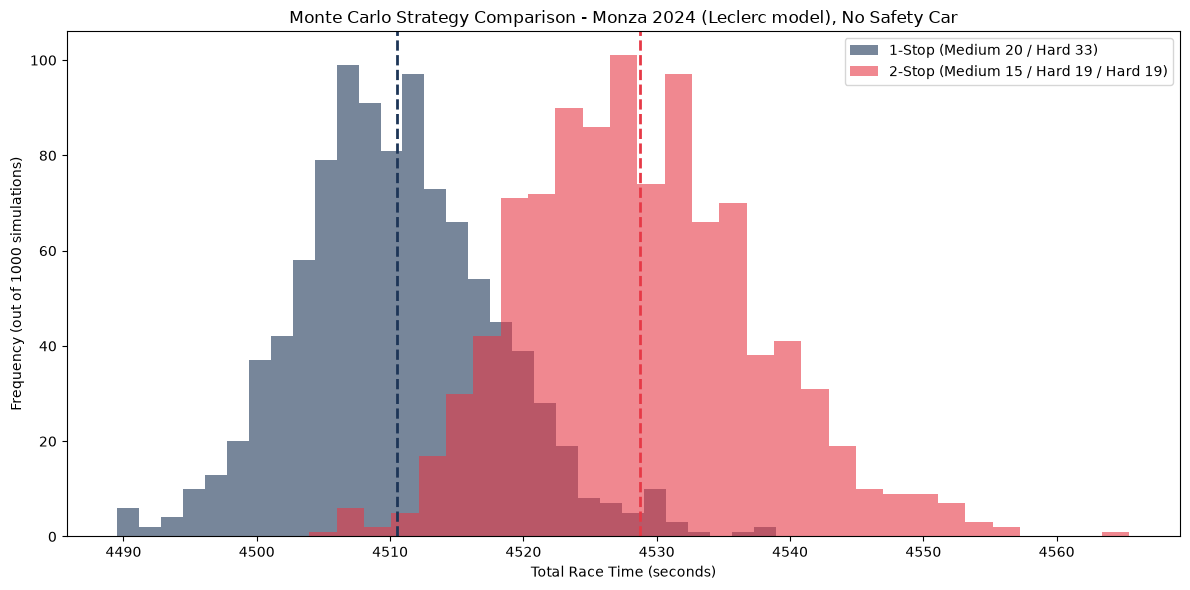

In [105]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(results_1stop, bins=30, alpha=0.6, color="#1d3557", label="1-Stop (Medium 20 / Hard 33)")
ax.hist(results_2stop, bins=30, alpha=0.6, color="#e63946", label="2-Stop (Medium 15 / Hard 19 / Hard 19)")

ax.axvline(results_1stop.mean(), color="#1d3557", linestyle="--", linewidth=2)
ax.axvline(results_2stop.mean(), color="#e63946", linestyle="--", linewidth=2)

ax.set_xlabel("Total Race Time (seconds)")
ax.set_ylabel("Frequency (out of 1000 simulations)")
ax.set_title("Monte Carlo Strategy Comparison - Monza 2024 (Leclerc model), No Safety Car")
ax.legend()
plt.tight_layout()
plt.show()

### Sensitivity analysis: does the safety car probability change the answer?

Each of the three safety car scenarios from Step 4 (none, the long-term Monza rate, and the rate from our own 2018-2024 data) is run for both strategies, with the same paired-seed approach.

In [106]:
# Compare both strategies across all three safety car scenarios defined in Step 4
sc_scenarios_lap = {name: race_to_lap_probability(p_race) for name, p_race in sc_scenarios.items()}

sensitivity_results = []

for scenario_name, p_lap in sc_scenarios_lap.items():
    res_1 = run_monte_carlo(strategy_1stop, total_laps=53, sc_probability=p_lap, n_simulations=n_sims, seed=42)
    res_2 = run_monte_carlo(strategy_2stop, total_laps=53, sc_probability=p_lap, n_simulations=n_sims, seed=42)

    diff = res_1 - res_2
    sensitivity_results.append({
        "Scenario": scenario_name,
        "p_lap": p_lap,
        "1-Stop Mean": res_1.mean(),
        "2-Stop Mean": res_2.mean(),
        "Difference": diff.mean(),
        "SE": diff.std() / np.sqrt(n_sims),
        "Faster Strategy": "1-Stop" if diff.mean() < 0 else "2-Stop",
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.to_string(index=False))

                       Scenario    p_lap  1-Stop Mean  2-Stop Mean  Difference       SE Faster Strategy
                  No safety car 0.000000  4510.505019  4528.721974  -18.216955 0.351191          1-Stop
Long-term Monza rate (STATS F1) 0.006441  4521.544219  4539.945419  -18.401200 0.849792          1-Stop
             Own data 2018-2024 0.015860  4537.359460  4555.231261  -17.871802 1.272830          1-Stop


**Result:** 1-Stop remains faster in all three scenarios, by a nearly constant ~18s margin (18.2s, 18.4s, 17.9s). The safety car lap-time factor (1.37x) affects both strategies almost equally, since both cover the same number of laps; the only strategy-specific lever - the smaller net pit loss under a safety car (22.49s vs 25.55s) - is too small relative to the structural ~18s gap to change the ranking, even at the higher of the two SC-probability scenarios.

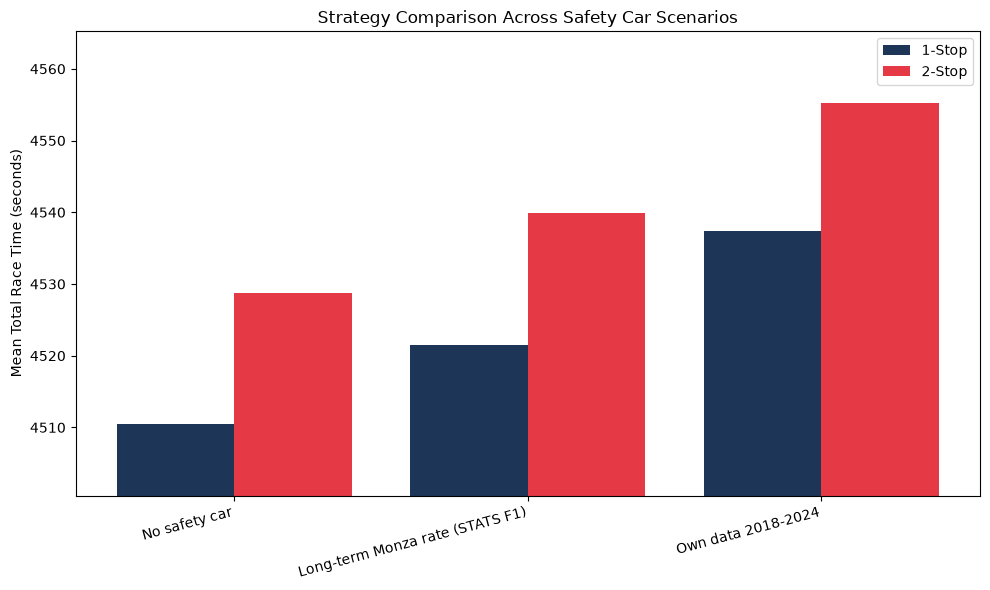

In [107]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(sensitivity_df))
ax.bar(x_pos - 0.2, sensitivity_df["1-Stop Mean"], width=0.4, color="#1d3557", label="1-Stop")
ax.bar(x_pos + 0.2, sensitivity_df["2-Stop Mean"], width=0.4, color="#e63946", label="2-Stop")

ax.set_xticks(x_pos)
ax.set_xticklabels(sensitivity_df["Scenario"], rotation=15, ha="right")
ax.set_ylabel("Mean Total Race Time (seconds)")
ax.set_ylim(sensitivity_df["1-Stop Mean"].min() - 10, sensitivity_df["2-Stop Mean"].max() + 10)
ax.set_title("Strategy Comparison Across Safety Car Scenarios")
ax.legend()
plt.tight_layout()
plt.show()

### Pit lap sweep: is lap 20 actually the best 1-stop timing?

Rather than comparing only the two strategies chosen by hand, the pit lap of the 1-stop strategy is swept across a realistic range to see whether an interior optimum exists.

In [108]:
# Sweep the 1-stop pit lap across a realistic range and find the time-minimizing lap
pit_lap_range = range(5, 49)  # pit lap must leave at least a few laps on each tyre
n_sims_sweep = 300            # fewer sims per point to keep runtime reasonable across ~44 points

sweep_results = []

for pit_lap in pit_lap_range:
    strategy = [("MEDIUM", pit_lap), ("HARD", 53 - pit_lap)]
    res = run_monte_carlo(strategy, total_laps=53, sc_probability=0.0, n_simulations=n_sims_sweep, seed=42)
    sweep_results.append({"PitLap": pit_lap, "MeanTime": res.mean()})

sweep_df = pd.DataFrame(sweep_results)
optimal_row = sweep_df.loc[sweep_df["MeanTime"].idxmin()]

print(f"Optimal pit lap: {int(optimal_row['PitLap'])}, mean race time: {optimal_row['MeanTime']:.2f}s")
print(f"(Previously tested: pit lap 20, mean time: {sweep_df.loc[sweep_df['PitLap'] == 20, 'MeanTime'].values[0]:.2f}s)")

Optimal pit lap: 5, mean race time: 4491.16s
(Previously tested: pit lap 20, mean time: 4511.40s)


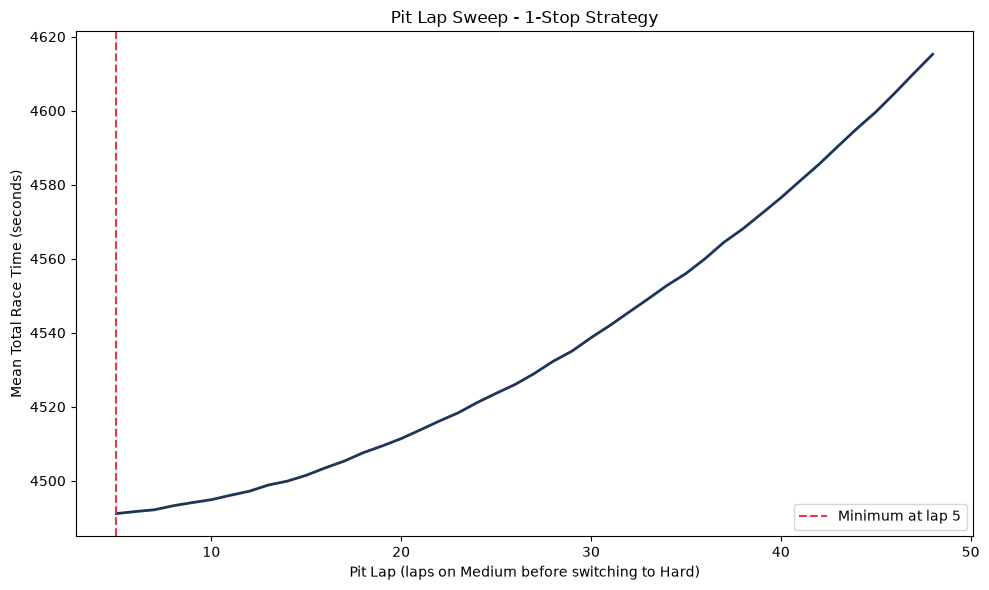

In [109]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep_df["PitLap"], sweep_df["MeanTime"], color="#1d3557", linewidth=2)
ax.axvline(int(optimal_row["PitLap"]), color="#e63946", linestyle="--", label=f"Minimum at lap {int(optimal_row['PitLap'])}")
ax.set_xlabel("Pit Lap (laps on Medium before switching to Hard)")
ax.set_ylabel("Mean Total Race Time (seconds)")
ax.set_title("Pit Lap Sweep - 1-Stop Strategy")
ax.legend()
plt.tight_layout()
plt.show()

**Result:** race time falls monotonically from lap 48 to lap 5 - the minimum sits at the edge of the tested range, not at an interior point. This looks less like a genuine optimal strategy and more like the model wanting to pit even earlier. Checked below.

In [110]:
# Decompose: how much of the saving when moving the pit lap earlier comes from 
# Medium degradation avoided vs. the (near-zero) Hard degradation picked up instead
for pit_lap in [10, 20, 30, 40]:
    medium_cost = sim_tyre_medium * sum(range(1, pit_lap + 1))      # cumulative Medium degradation cost
    hard_laps = 53 - pit_lap
    hard_cost = sim_tyre_hard * sum(range(1, hard_laps + 1))        # cumulative Hard degradation cost
    print(f"Pit lap {pit_lap}: Medium degradation cost = {medium_cost:.2f}s | Hard degradation cost = {hard_cost:.2f}s")

Pit lap 10: Medium degradation cost = 6.13s | Hard degradation cost = -2.25s
Pit lap 20: Medium degradation cost = 23.42s | Hard degradation cost = -1.33s
Pit lap 30: Medium degradation cost = 51.85s | Hard degradation cost = -0.66s
Pit lap 40: Medium degradation cost = 91.44s | Hard degradation cost = -0.22s


In [111]:
# Restrict the sweep to the range we actually have degradation data for (TyreLife > 4 was the cutoff)
pit_lap_range_restricted = range(10, 49)

sweep_results_r = []
for pit_lap in pit_lap_range_restricted:
    strategy = [("MEDIUM", pit_lap), ("HARD", 53 - pit_lap)]
    res = run_monte_carlo(strategy, total_laps=53, sc_probability=0.0, n_simulations=n_sims_sweep, seed=42)
    sweep_results_r.append({"PitLap": pit_lap, "MeanTime": res.mean()})

sweep_df_r = pd.DataFrame(sweep_results_r)
optimal_row_r = sweep_df_r.loc[sweep_df_r["MeanTime"].idxmin()]
print(f"Optimal pit lap (restricted to >=10): {int(optimal_row_r['PitLap'])}, mean race time: {optimal_row_r['MeanTime']:.2f}s")

Optimal pit lap (restricted to >=10): 10, mean race time: 4494.90s


### Limitation: no interior optimum under the linear degradation model

The decomposition confirms why: Medium's cost grows quadratically with stint length (a constant per-lap degradation rate, summed over an increasing number of laps), while Hard's near-zero/slightly-negative slope contributes almost nothing regardless of stint length. A linear degradation model is structurally unable to produce an interior minimum here - it can only push toward one edge of the tested range. The restricted sweep (laps 10-48, the range covered by actual degradation data) confirms the same edge behaviour.

Realistic tyre behaviour (an initial out-lap/warm-up phase, a stable middle phase, and possibly a late-stint "cliff" as hinted at in the Medium stint in Part 1) would require a non-linear model, e.g. quadratic in `TyreLife`, to locate a genuine interior optimum. This is left for future work; the pit lap sweep is reported here as a diagnostic of the linear model's limits, not as a claim about the actual optimal Monza pit window.

## Conclusion

- **1-Stop (Medium 20 / Hard 33) beats 2-Stop (Medium 15 / Hard 19 / Hard 19) by about 18s on average**, robust across all three safety car probability scenarios tested (95% interval excludes zero in every case).
- This result is **conditional on Leclerc's own observed tyre behaviour** in this race: his Hard-compound degradation was measured as near zero (even slightly negative), which is specific to him (field-wide Hard degradation was 0.0809 s/lap) and not a general Monza/Hard-compound property.
- The safety car shifts absolute race time but barely changes the strategy ranking, because the lap-time factor (1.37x) hits both strategies almost equally, and the pit-stop saving under a safety car (~3s, itself only weakly supported by n=15 historical stops) is small relative to the ~18s structural gap.
- A systematic pit-lap sweep found no interior optimum: the linear degradation model pushes toward pitting as early as possible, a direct consequence of Medium's quadratically growing cost under a constant per-lap degradation rate. This is a genuine limitation of the linear model, not a validated strategic finding, and a non-linear degradation model is the natural next step.
- **Explicitly out of scope:** driver error, weather changes, tyre allocation rules, opponent strategy reactions, and the undercut effect (requires a multi-car model) - see the notes throughout this notebook.